In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [2]:
import torch
from custom_vision_transformer import vit_custom
from training_utils import get_data_loaders
from types import SimpleNamespace
import matplotlib.pyplot as plt
from utils import *
from training_utils import val_one_epoch

In [3]:
params = SimpleNamespace(
    gpu_idx=0,
    num_classes=100,
    img_size=224,
    batch_size=128,
    checkpoint_path="training_checkpoints/checkpoint1/vit_custom_epoch_200.pth",
    use_bias=True,
    bias_threshold=None,
    bias_topk=None,
    bias_score_threshold=None,
    bias_random_prune=None,
    bias_only=[False]*8 + [True]*4
)

In [4]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3
Device: cuda:0 NVIDIA GeForce RTX 2080 Ti


In [5]:
model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=params.use_bias, bias_threshold=params.bias_threshold, bias_topk=params.bias_topk, bias_score_threshold=params.bias_score_threshold, bias_random_prune=params.bias_random_prune, bias_only=params.bias_only).to(device)
checkpoint = torch.load(params.checkpoint_path, map_location=device)
checkpoint = checkpoint["model_state_dict"]
checkpoint = convert_qkv_to_q_k_v(checkpoint)
model.load_state_dict(checkpoint)
model.eval();

/tmp/ipykernel_305520/1272900084.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(params.checkpoint_path, map_location=device)


In [6]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

In [7]:
avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
print(f"Validation Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Validation Accuracy: 0.7716, Top-5 Accuracy: 0.9162, Average Pruning Ratio: 0.0000


TopK: 1.000, Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


TopK: 0.900, Accuracy: 0.7906, Top-5 Accuracy: 0.9214, Average Pruning Ratio: 0.1015


TopK: 0.800, Accuracy: 0.7854, Top-5 Accuracy: 0.9170, Average Pruning Ratio: 0.2030


TopK: 0.700, Accuracy: 0.7794, Top-5 Accuracy: 0.9134, Average Pruning Ratio: 0.3046


TopK: 0.600, Accuracy: 0.7684, Top-5 Accuracy: 0.9088, Average Pruning Ratio: 0.4010


...

TopK: 0.600, Accuracy: 0.7742, Top-5 Accuracy: 0.9102, Average Pruning Ratio: 0.4010


TopK: 0.550, Accuracy: 0.7578, Top-5 Accuracy: 0.9020, Average Pruning Ratio: 0.4518


TopK: 0.600, Accuracy: 0.7766, Top-5 Accuracy: 0.9132, Average Pruning Ratio: 0.4036


TopK: 0.650, Accuracy: 0.7826, Top-5 Accuracy: 0.9150, Average Pruning Ratio: 0.3528


TopK: 0.650, Accuracy: 0.7804, Top-5 Accuracy: 0.9134, Average Pruning Ratio: 0.3528


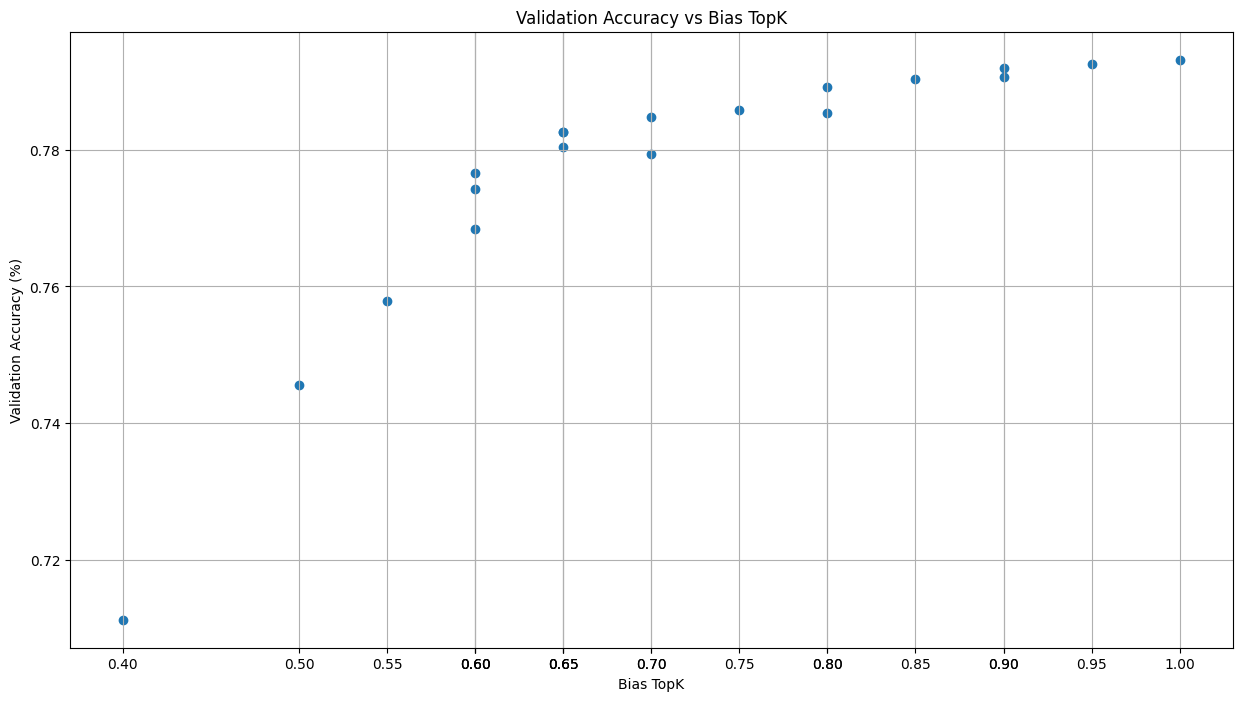

In [42]:
# plot accuracy en fonction du topk

topk_values = [[1.0]*12, [0.9]*12, [0.8]*12, [0.7]*12, [0.6]*12, [0.5]*12, [0.4]*12,
               [1.0]*6 + [0.9]*6, [1.0]*6 + [0.8]*6, [1.0]*6 + [0.7]*6, [1.0]*6 + [0.6]*6, [1.0]*6 + [0.5]*6, [1.0]*6 + [0.4]*6, [1.0]*6 + [0.3]*6, [1.0]*6 + [0.2]*6, [1.0]*6 + [0.1]*6,
               [0.8]*6 + [0.4]*6, [0.9]*6 + [0.4]*6, [0.8]*6 + [0.5]*6]
acc_values = []

for topk in topk_values:
    model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=None, bias_topk=topk).to(device)
    checkpoint = torch.load(params.checkpoint_path, map_location=device)
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval();

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    print(f"TopK: {(mean(topk)):.3f}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.figure(figsize=(15, 8))
plt.scatter([mean(k) for k in topk_values], acc_values, marker='o')
plt.title("Validation Accuracy vs Bias TopK")
plt.xlabel("Bias TopK")
plt.ylabel("Validation Accuracy (%)")
plt.xticks([mean(k) for k in topk_values])
plt.grid()
plt.show()

Threshold: -3.000, Accuracy: 0.7944, Top-5 Accuracy: 0.9236, Average Pruning Ratio: 0.0149


Threshold: -2.500, Accuracy: 0.7942, Top-5 Accuracy: 0.9234, Average Pruning Ratio: 0.0487


Threshold: -2.000, Accuracy: 0.7944, Top-5 Accuracy: 0.9226, Average Pruning Ratio: 0.1168


Threshold: -1.500, Accuracy: 0.7900, Top-5 Accuracy: 0.9236, Average Pruning Ratio: 0.2198


Threshold: -1.000, Accuracy: 0.7812, Top-5 Accuracy: 0.9182, Average Pruning Ratio: 0.3522


Threshold: -0.500, Accuracy: 0.7598, Top-5 Accuracy: 0.9058, Average Pruning Ratio: 0.5134


Threshold: 0.000, Accuracy: 0.6842, Top-5 Accuracy: 0.8578, Average Pruning Ratio: 0.6914


Threshold: 0.500, Accuracy: 0.4612, Top-5 Accuracy: 0.6704, Average Pruning Ratio: 0.8162


Threshold: 1.000, Accuracy: 0.1852, Top-5 Accuracy: 0.3668, Average Pruning Ratio: 0.8718


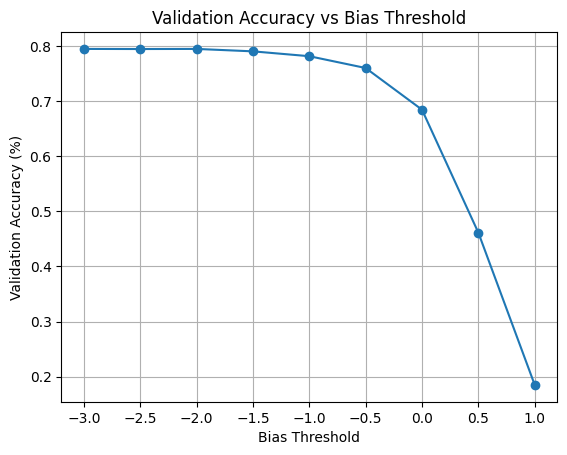

In [37]:
# plot accuracy en fonction du nombre de neurones prunés (threshold)

threshold_values = [-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]
acc_values = []
avg_pruned_ratio_values = []

for threshold in threshold_values:
    model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=threshold, bias_topk=None).to(device)
    checkpoint = torch.load(params.checkpoint_path, map_location=device)
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval();

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    avg_pruned_ratio_values.append(avg_pruned_ratio)
    print(f"Threshold: {threshold:.3f}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.plot(threshold_values, acc_values, marker='o')
plt.title("Validation Accuracy vs Bias Threshold")
plt.xlabel("Bias Threshold")
plt.ylabel("Validation Accuracy (%)")
plt.xticks(threshold_values)
plt.grid()
plt.show()

Score Threshold: 1.000, Accuracy: 0.7932, Top-5 Accuracy: 0.9230, Average Pruning Ratio: 0.0015


Score Threshold: 0.950, Accuracy: 0.7820, Top-5 Accuracy: 0.9166, Average Pruning Ratio: 0.2246


Score Threshold: 0.900, Accuracy: 0.7696, Top-5 Accuracy: 0.9134, Average Pruning Ratio: 0.3441


Score Threshold: 0.850, Accuracy: 0.7652, Top-5 Accuracy: 0.9070, Average Pruning Ratio: 0.4321


Score Threshold: 0.800, Accuracy: 0.7412, Top-5 Accuracy: 0.8934, Average Pruning Ratio: 0.5032


...

Score Threshold: 0.875, Accuracy: 0.7772, Top-5 Accuracy: 0.9136, Average Pruning Ratio: 0.3786


Score Threshold: 0.825, Accuracy: 0.7732, Top-5 Accuracy: 0.9126, Average Pruning Ratio: 0.4367


Score Threshold: 0.900, Accuracy: 0.7696, Top-5 Accuracy: 0.9134, Average Pruning Ratio: 0.3438


Score Threshold: 0.850, Accuracy: 0.7694, Top-5 Accuracy: 0.9102, Average Pruning Ratio: 0.4313


Score Threshold: 0.800, Accuracy: 0.7622, Top-5 Accuracy: 0.9076, Average Pruning Ratio: 0.4899


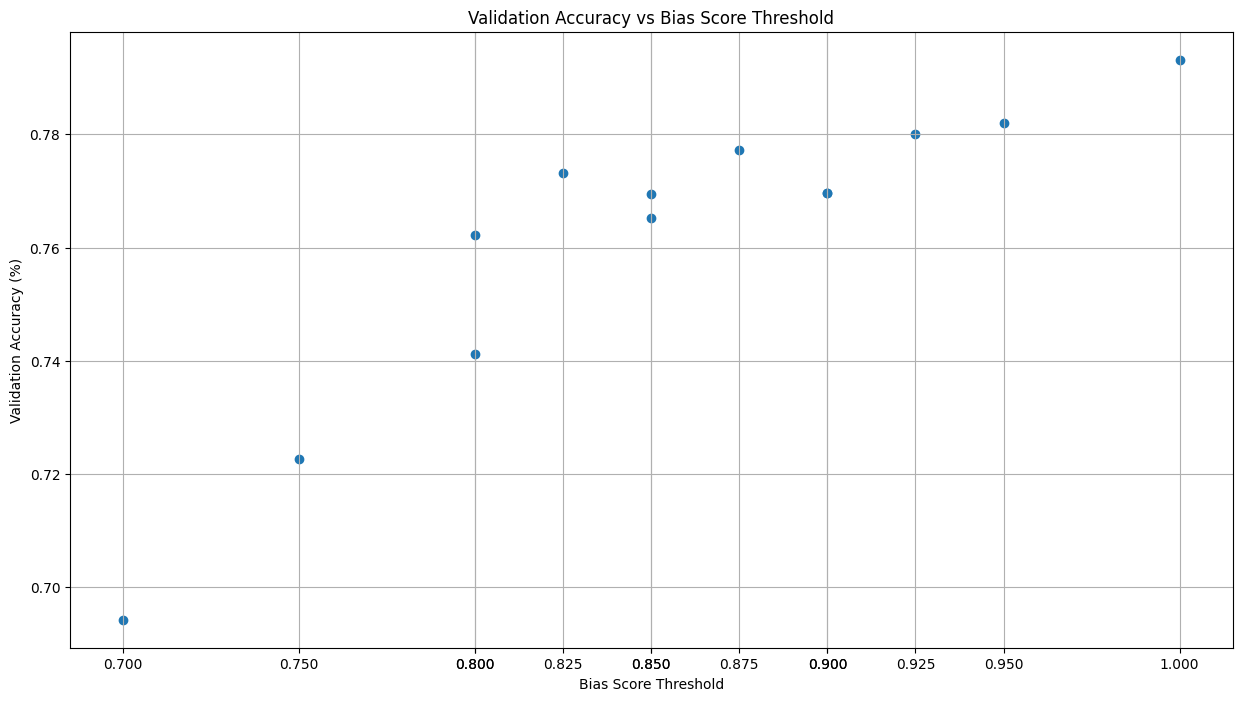

In [41]:
# plot accuracy en fonction du nombre de neurones prunés (score threshold)

score_threshold_values = [[1.0]*12, [0.95]*12, [0.9]*12, [0.85]*12, [0.8]*12, [0.75]*12, [0.7]*12,
                          [0.95]*6 + [0.9]*6, [0.95]*6 + [0.8]*6, [0.95]*6 + [0.7]*6,
                          [0.90]*6 + [0.9]*6, [0.90]*6 + [0.8]*6, [0.90]*6 + [0.7]*6]
acc_values = []
avg_pruned_ratio_values = []

for threshold in score_threshold_values:
    model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=None, bias_topk=None, bias_score_threshold=threshold).to(device)
    checkpoint = torch.load(params.checkpoint_path, map_location=device)
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval();

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    avg_pruned_ratio_values.append(avg_pruned_ratio)
    print(f"Score Threshold: {mean(threshold):.3f}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.figure(figsize=(15, 8))
plt.scatter([mean(t) for t in score_threshold_values], acc_values, marker='o')
plt.title("Validation Accuracy vs Bias Score Threshold")
plt.xlabel("Bias Score Threshold")
plt.ylabel("Validation Accuracy (%)")
plt.xticks([mean(t) for t in score_threshold_values])
plt.grid()
plt.show()

Prune Ratio: 1.000, Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


Prune Ratio: 0.900, Accuracy: 0.7882, Top-5 Accuracy: 0.9194, Average Pruning Ratio: 0.1015


Prune Ratio: 0.800, Accuracy: 0.7782, Top-5 Accuracy: 0.9168, Average Pruning Ratio: 0.2030


Prune Ratio: 0.700, Accuracy: 0.7710, Top-5 Accuracy: 0.9144, Average Pruning Ratio: 0.3046


Prune Ratio: 0.600, Accuracy: 0.7622, Top-5 Accuracy: 0.9072, Average Pruning Ratio: 0.4010


...

Prune Ratio: 0.400, Accuracy: 0.7316, Top-5 Accuracy: 0.8970, Average Pruning Ratio: 0.6041


Prune Ratio: 0.300, Accuracy: 0.6980, Top-5 Accuracy: 0.8772, Average Pruning Ratio: 0.7005


Prune Ratio: 0.200, Accuracy: 0.6340, Top-5 Accuracy: 0.8368, Average Pruning Ratio: 0.8020


Prune Ratio: 0.100, Accuracy: 0.4582, Top-5 Accuracy: 0.7132, Average Pruning Ratio: 0.9036


Prune Ratio: 0.000, Accuracy: 0.0732, Top-5 Accuracy: 0.2026, Average Pruning Ratio: 0.9949


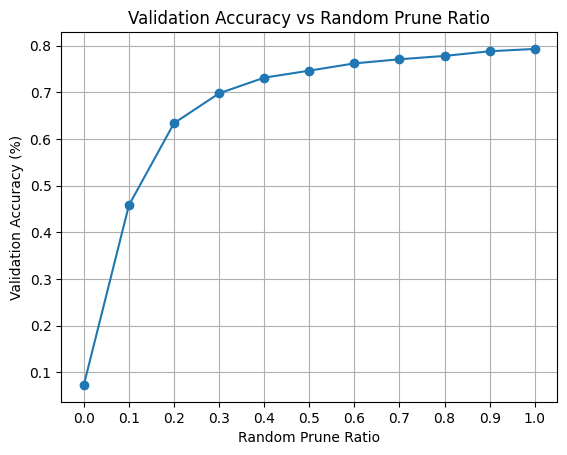

In [8]:
# plot accuracy en fonction du nombre de neurones prunés (random pruning)

random_prune_values = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0]
acc_values = []
avg_pruned_ratio_values = []

for prune_ratio in random_prune_values:
    model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=None, bias_topk=None, bias_random_prune=prune_ratio).to(device)
    checkpoint = torch.load(params.checkpoint_path, map_location=device)
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval();

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    avg_pruned_ratio_values.append(avg_pruned_ratio)
    print(f"Prune Ratio: {prune_ratio:.3f}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.plot(random_prune_values, acc_values, marker='o')
plt.title("Validation Accuracy vs Random Prune Ratio")
plt.xlabel("Random Prune Ratio")
plt.ylabel("Validation Accuracy (%)")
plt.xticks(random_prune_values)
plt.grid()
plt.show()